# **Machine Learning Final Project Spring 2026**
## **ML to Predict Material Properties with CGCNN (Xie et al. 2018)**
### Aletta Bartok

# **Overview**
This notebook implements and explores the Crystal Graph Convolutional Neural Network (CGCNN) framework, as introduced by Xie et al. (2018). This model represents a shift in computational materials science by addressing the limitations of traditional machine learning (ML) and Density Functional Theory (DFT) methods.

Standard ML algorithms often require fixed-length vectors as input, making them incompatible with crystal systems of arbitrary size and shape. Traditionally, scientists bypassed this via manual feature engineering, which is time-consuming and results in models that lack physical interpretability.

CGCNN treats crystals as undirected graphs, where the atoms are nodes and the bonds are edges. It learns material properties from atomic connections, eliminating the need for manual feature engineering. It also provides DFT-level accuracy but several orders of magnitude faster, enabling high-throughput screening of massive material librairies. Through specialized pooling layers, the model remains invariant to different ways of representing the same crystal.

Here, the hyperparameters are varied and explored by looking at the effects of convolutional layers, training data size, test/validation/train split, and batch size. Through this exploration, the goal is to gain a deeper understanding of CGCNN and the applications of ML for materials science and engineering.

## **GitHub Repository**
Aletta's GitHub Repository, created for this project, includes: all data for calculations and analysis, this `.ipynb` file, and a README for more information.

The GitHub Repository is located at: https://github.com/barto554/Bartok-ML-MatProperties

### **NOTE:**
When running this notebook, each cell must be run separately. As the CGCNN model outputs results with certain names, there is a line of code for each result that renames the files automatically. To ensure this is accurate and there are no issues, each line must be run separately. Also, the results from each run and model vary each time it is run, due to the nature of the neural network. For analysis, a fixed dataset is used from earlier calculations, provided from the imported GitHub repository.

# **Import Modules**

In [ ]:
!pip install torch
!pip install scikit-learn
!pip install pymatgen

import torch
import numpy as np
import random
import os
import shutil
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# **Import Xie et al. (2018) Code and Files**

In [ ]:
# Import CGCNN from Github
if not os.path.exists('cgcnn'):
    !git clone https://github.com/txie-93/cgcnn.git
else:
    print('cgcnn directory already exists. Skipping git clone.')

cgcnn directory already exists. Skipping git clone.


# **Import Data**

## **Specific Molecules Used**
The molecules used for training the model are outlined here. As we are precicting band gap, the band gaps for each molecule are specified, taken from the Materials Project Database.

**10 Molecules** were provided by Xie et al. (2018):
- $NaCl$ - 5.00
- $KCl$ - 4.80
- $ZnS$ - 2.02
- $BaTiO_3$ - 1.73
- $TiO_2$ - 2.06
- $C$ $(Graphite)$ - 0.00
- $CsCl$ - 4.99
- $Ge$ - 0.00
- $Si$ - 0.61
- $C$ $(Diamond)$ - 4.11

Added **5 molecules** to the training dataset for the small train/test split:
- $LiH$ - 2.98
- $NaH$ - 3.77
- $HBr$ - 4.68
- $FeH$ - 0.00
- $SnO$ - 0.41

Added **15 more molecules** to the training dataset for the large train/test split:
- $LiP$ - 0.81
- $CrF_6$ - 2.09
- $NaAs$ - 0.57
- $UCl_6$ - 1.58
- $ZnAs_2$ - 0.22
- $CuGe_2P_3$ - 0.00
- $FeO$ - 1.82
- $CoF_2$ - 2.27
- $KN_3$ - 3.90
- $KSb$ - 0.82
- $VO_2$ - 0.76
- $Zr_2Ni$ - 0.00
- $TiGa$ - 0.00
- $Co_3Ni$ - 0.00
- $Ag$ - 0.00

**5 Molecules** were used for predicting to test the ability of the best model:
- $KH$ - 3.43
- $CaS$ - 2.38
- $Ti_6O$ - 0.00
- $CuO$ - 0.45
- $Rb_2O$ - 0.00

The band gap values are placed into a file named ```id_prop.csv``` which is is the "answer key" for the model, which is the file the model checks after it predicts the value. Through this file, the model is able to learn, in this case the band gap, based on the structure of the molecule. Another file ```atom_init.json``` is also included in the file, which assigns a vector to each element, which is how the model "knows" what a specific atom is before it even looks at the bonds.

## **Import pre-published files for this from GitHub Repository:**
As mentioned, I have created a GitHub repository for all of the data files used for this project. There is a README file included describing the project and the files, similar to what is included here in this notebook. The following are the datasets, with the molecules described above, and their functions and descriptions.

**root_dir_smallset:** All molecules from researchers plus 5 new molecules.

**root_dir_largeset:** All molecules (from researchers, small dataset, plus 15 new molecules).

**predict_dir:** 5 molecules for predicting, same across all datasets for consistent testing.

In [ ]:
# Import Data
if not os.path.exists('Bartok-ML-MatProperties'): # If/else function to ensure this runs and works, even if error occurs or has already been run before.
    !git clone https://github.com/barto554/Bartok-ML-MatProperties
else:
    print('Bartok-ML-MatProperties directory already exists. Skipping git clone.')

Bartok-ML-MatProperties directory already exists. Skipping git clone.


# **Run the pretrained band gap model**
As a baseline for data collection with varied initial conditions, run the pretrained model as a reference for analysis and to ensure CGCNN is installed.

In [ ]:
!python /content/cgcnn/predict.py /content/cgcnn/pre-trained/band-gap.pth.tar /content/Bartok-ML-MatProperties/predict_dir   # Run the model to predict the results
!mv test_results.csv pretrained_results.csv   # Rename it instantly to ensure the file is saved and stored for future analysis

=> loading model params '/content/cgcnn/pre-trained/band-gap.pth.tar'
=> loaded model params '/content/cgcnn/pre-trained/band-gap.pth.tar'
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 14 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
=> loading model '/content/cgcnn/pre-trained/band-gap.pth.tar'
=> loaded model '/content/cgcnn/pre-trained/band-gap.pth.tar' (epoch 457, validation 0.3689685452196309)
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
Test: [0/1]	Time 0.171 (0.171)	Loss 0.0348 (0.0348)	MAE 0.237 (0.237)
 ** MAE 0.237


# **Perform Calculations**

## **Varied Convolutional Layers**
Vary the convolutional layers in the model from 0 to 5 to see the effect of these layers on the MAE and loss. This is performed on the `root_dir_smallset` data to find the best model with an optimal number of convolutional layers.

The number of convolutional layers are toggled with the command `--n-conv #`. The train, validation and test ratio are specified, while they are kept the same as the original, to ensure that all molecules are accounted for through a ratio command. This is using `--train-ratio 0.6`, `--val-ratio 0.2`, and `--test-ratio 0.2`.

### **1. Create the Best-Fit Models for each number of layers**

In [27]:
# 0 convolutional layers
!python /content/cgcnn/main.py /content/Bartok-ML-MatProperties/root_dir_smallset --n-conv 0 --train-ratio 0.6 --val-ratio 0.2 --test-ratio 0.2  # Run the code to create the best-fit model
!mv checkpoint.pth.tar 0_conv_layers_checkpoint.pth.tar   # Rename best model files instantly to ensure the file is saved and stored for future analysis
!mv model_best.pth.tar 0_conv_layers_model_best.pth.tar   # Rename checkpoint file instantly to ensure the file is saved and stored for future analysis
!mv test_results.csv 0_conv_layers_results.csv   # Rename test results file instantly to ensure the file is saved and stored for future analysis

/content/cgcnn/main.py:117: UserWarning: Dataset has less than 500 data points. Lower accuracy is expected. 
  warnings.warn('Dataset has less than 500 data points. '
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
Epoch: [0][0/1]	Time 0.006 (0.006)	Data 0.001 (0.001)	Loss 0.8236 (0.8236)	MAE 1.528 (1.528)
Test: [0/1]	Time 0.001 (0.001)	Loss 0.9788 (0.9788)	MAE 1.699 (1.699)
 * MAE 1.699
Epoch: [1][0/1]	Time 0.002 (0.002)	Data 0.001 (0.001)	Loss 0.7762 (0.7762)	MAE 1.481 (1.481)
Test: [0/1]	Time 0.001 (0.001)	Loss 0.9975 (0.9975)	MAE 1.807 (1.807)
 * MAE 1.807
Epoch: [2][0/1]	Time 0.002 (0.002)	Data 0.001 (0.001)	Loss 0.8348 (0.8348)	MAE 1.589 (1.589)
Test: [0/1]	Time 0.001 (0.001)	Loss 0.9820 (0.9820)	MAE 1.662 (1.662)
 * MAE 1.662
Epoch: [3][0/1]	Time 0.002 (0.002)

In [28]:
# 1 convolutional layer
!python /content/cgcnn/main.py /content/Bartok-ML-MatProperties/root_dir_smallset --n-conv 1 --train-ratio 0.6 --val-ratio 0.2 --test-ratio 0.2  # Run the code to create the best-fit model
!mv checkpoint.pth.tar 1_conv_layers_checkpoint.pth.tar   # Rename best model files instantly to ensure the file is saved and stored for future analysis
!mv model_best.pth.tar 1_conv_layers_model_best.pth.tar   # Rename checkpoint file instantly to ensure the file is saved and stored for future analysis
!mv test_results.csv 1_conv_layers_results.csv   # Rename test results file instantly to ensure the file is saved and stored for future analysis

/content/cgcnn/main.py:117: UserWarning: Dataset has less than 500 data points. Lower accuracy is expected. 
  warnings.warn('Dataset has less than 500 data points. '
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
Epoch: [0][0/1]	Time 0.021 (0.021)	Data 0.001 (0.001)	Loss 0.8090 (0.8090)	MAE 1.511 (1.511)
Test: [0/1]	Time 0.002 (0.002)	Loss 1.0108 (1.0108)	MAE 1.851 (1.851)
 * MAE 1.851
Epoch: [1][0/1]	Time 0.017 (0.017)	Data 0.001 (0.001)	Loss 0.7827 (0.7827)	MAE 1.514 (1.514)
Test: [0/1]	Time 0.002 (0.002)	Loss 0.9605 (0.9605)	MAE 1.772 (1.772)
 * MAE 1.772
Epoch: [2][0/1]	Time 0.017 (0.017)	Data 0.001 (0.001)	Loss 0.7379 (0.7379)	MAE 1.475 (1.475)
Test: [0/1]	Time 0.002 (0.002)	Loss 0.9481 (0.9481)	MAE 1.585 (1.585)
 * MAE 1.585
Epoch: [3][0/1]	Time 0.018 (0.018)

In [29]:
# 2 convolutional layers
!python /content/cgcnn/main.py /content/Bartok-ML-MatProperties/root_dir_smallset --n-conv 2 --train-ratio 0.6 --val-ratio 0.2 --test-ratio 0.2  # Run the code to create the best-fit model
!mv checkpoint.pth.tar 2_conv_layers_checkpoint.pth.tar   # Rename best model files instantly to ensure the file is saved and stored for future analysis
!mv model_best.pth.tar 2_conv_layers_model_best.pth.tar   # Rename checkpoint file instantly to ensure the file is saved and stored for future analysis
!mv test_results.csv 2_conv_layers_results.csv   # Rename test results file instantly to ensure the file is saved and stored for future analysis

/content/cgcnn/main.py:117: UserWarning: Dataset has less than 500 data points. Lower accuracy is expected. 
  warnings.warn('Dataset has less than 500 data points. '
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
Epoch: [0][0/1]	Time 0.038 (0.038)	Data 0.001 (0.001)	Loss 0.8864 (0.8864)	MAE 1.601 (1.601)
Test: [0/1]	Time 0.004 (0.004)	Loss 2.9037 (2.9037)	MAE 2.648 (2.648)
 * MAE 2.648
Epoch: [1][0/1]	Time 0.033 (0.033)	Data 0.001 (0.001)	Loss 0.6854 (0.6854)	MAE 1.412 (1.412)
Test: [0/1]	Time 0.004 (0.004)	Loss 1.2438 (1.2438)	MAE 1.832 (1.832)
 * MAE 1.832
Epoch: [2][0/1]	Time 0.032 (0.032)	Data 0.001 (0.001)	Loss 0.4082 (0.4082)	MAE 1.089 (1.089)
Test: [0/1]	Time 0.004 (0.004)	Loss 0.9359 (0.9359)	MAE 1.617 (1.617)
 * MAE 1.617
Epoch: [3][0/1]	Time 0.032 (0.032)

In [30]:
# 3 convolutional Layers
!python /content/cgcnn/main.py /content/Bartok-ML-MatProperties/root_dir_smallset --n-conv 3 --train-ratio 0.6 --val-ratio 0.2 --test-ratio 0.2  # Run the code to create the best-fit model
!mv checkpoint.pth.tar 3_conv_layers_checkpoint.pth.tar   # Rename best model files instantly to ensure the file is saved and stored for future analysis
!mv model_best.pth.tar 3_conv_layers_model_best.pth.tar   # Rename checkpoint file instantly to ensure the file is saved and stored for future analysis
!mv test_results.csv 3_conv_layers_results.csv   # Rename test results file instantly to ensure the file is saved and stored for future analysis

/content/cgcnn/main.py:117: UserWarning: Dataset has less than 500 data points. Lower accuracy is expected. 
  warnings.warn('Dataset has less than 500 data points. '
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
Epoch: [0][0/1]	Time 0.080 (0.080)	Data 0.003 (0.003)	Loss 2.0091 (2.0091)	MAE 2.438 (2.438)
Test: [0/1]	Time 0.006 (0.006)	Loss 209.5145 (209.5145)	MAE 28.505 (28.505)
 * MAE 28.505
Epoch: [1][0/1]	Time 0.063 (0.063)	Data 0.001 (0.001)	Loss 7.7437 (7.7437)	MAE 5.248 (5.248)
Test: [0/1]	Time 0.007 (0.007)	Loss 78.2685 (78.2685)	MAE 17.399 (17.399)
 * MAE 17.399
Epoch: [2][0/1]	Time 0.063 (0.063)	Data 0.001 (0.001)	Loss 11.7559 (11.7559)	MAE 6.641 (6.641)
Test: [0/1]	Time 0.006 (0.006)	Loss 1.2279 (1.2279)	MAE 1.814 (1.814)
 * MAE 1.814
Epoch: [3][0/1]	Time

In [31]:
# 4 convolutional Layers
!python /content/cgcnn/main.py /content/Bartok-ML-MatProperties/root_dir_smallset --n-conv 4 --train-ratio 0.6 --val-ratio 0.2 --test-ratio 0.2  # Run the code to create the best-fit model
!mv checkpoint.pth.tar 4_conv_layers_checkpoint.pth.tar   # Rename best model files instantly to ensure the file is saved and stored for future analysis
!mv model_best.pth.tar 4_conv_layers_model_best.pth.tar   # Rename checkpoint file instantly to ensure the file is saved and stored for future analysis
!mv test_results.csv 4_conv_layers_results.csv   # Rename test results file instantly to ensure the file is saved and stored for future analysis

/content/cgcnn/main.py:117: UserWarning: Dataset has less than 500 data points. Lower accuracy is expected. 
  warnings.warn('Dataset has less than 500 data points. '
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
Epoch: [0][0/1]	Time 0.067 (0.067)	Data 0.001 (0.001)	Loss 3.1375 (3.1375)	MAE 3.073 (3.073)
Test: [0/1]	Time 0.006 (0.006)	Loss 2730.7920 (2730.7920)	MAE 103.217 (103.217)
 * MAE 103.217
Epoch: [1][0/1]	Time 0.061 (0.061)	Data 0.001 (0.001)	Loss 24.2060 (24.2060)	MAE 9.041 (9.041)
Test: [0/1]	Time 0.006 (0.006)	Loss 455.9220 (455.9220)	MAE 42.145 (42.145)
 * MAE 42.145
Epoch: [2][0/1]	Time 0.060 (0.060)	Data 0.001 (0.001)	Loss 18.7459 (18.7459)	MAE 8.454 (8.454)
Test: [0/1]	Time 0.006 (0.006)	Loss 2.4524 (2.4524)	MAE 2.489 (2.489)
 * MAE 2.489
Epoch: [3][

In [32]:
# 5 convolutional Layers
!python /content/cgcnn/main.py /content/Bartok-ML-MatProperties/root_dir_smallset --n-conv 5 --train-ratio 0.6 --val-ratio 0.2 --test-ratio 0.2  # Run the code to create the best-fit model
!mv checkpoint.pth.tar 5_conv_layers_checkpoint.pth.tar   # Rename best model files instantly to ensure the file is saved and stored for future analysis
!mv model_best.pth.tar 5_conv_layers_model_best.pth.tar   # Rename checkpoint file instantly to ensure the file is saved and stored for future analysis
!mv test_results.csv 5_conv_layers_results.csv   # Rename test results file instantly to ensure the file is saved and stored for future analysis

/content/cgcnn/main.py:117: UserWarning: Dataset has less than 500 data points. Lower accuracy is expected. 
  warnings.warn('Dataset has less than 500 data points. '
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
Epoch: [0][0/1]	Time 0.082 (0.082)	Data 0.001 (0.001)	Loss 1.0502 (1.0502)	MAE 1.727 (1.727)
Test: [0/1]	Time 0.008 (0.008)	Loss 492.0938 (492.0938)	MAE 43.813 (43.813)
 * MAE 43.813
Epoch: [1][0/1]	Time 0.076 (0.076)	Data 0.001 (0.001)	Loss 0.4569 (0.4569)	MAE 1.113 (1.113)
Test: [0/1]	Time 0.008 (0.008)	Loss 192.8058 (192.8058)	MAE 27.313 (27.313)
 * MAE 27.313
Epoch: [2][0/1]	Time 0.074 (0.074)	Data 0.001 (0.001)	Loss 1.6386 (1.6386)	MAE 2.088 (2.088)
Test: [0/1]	Time 0.007 (0.007)	Loss 854.3787 (854.3787)	MAE 57.738 (57.738)
 * MAE 57.738
Epoch: [3][0/

### **2. Test predicting capability of each best-fit model on predict_dir**

In [33]:
# 0 convolutional Layers
!python /content/cgcnn/predict.py /content/0_conv_layers_model_best.pth.tar /content/Bartok-ML-MatProperties/predict_dir # Run the model to predict the results
!mv test_results.csv 0_conv_layers_predict_results.csv   # Rename test results file instantly to ensure the file is saved and stored for future analysis

=> loading model params '/content/0_conv_layers_model_best.pth.tar'
=> loaded model params '/content/0_conv_layers_model_best.pth.tar'
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 14 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
=> loading model '/content/0_conv_layers_model_best.pth.tar'
=> loaded model '/content/0_conv_layers_model_best.pth.tar' (epoch 29, validation 1.5215282440185547)
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
Test: [0/1]	Time 0.068 (0.068)	Loss 0.5574 (0.5574)	MAE 1.400 (1.400)
 ** MAE 1.400


In [34]:
# 1 convolutional layer
!python /content/cgcnn/predict.py /content/1_conv_layers_model_best.pth.tar /content/Bartok-ML-MatProperties/predict_dir # Run the model to predict the results
!mv test_results.csv 1_conv_layers_predict_results.csv   # Rename test results file instantly to ensure the file is saved and stored for future analysis

=> loading model params '/content/1_conv_layers_model_best.pth.tar'
=> loaded model params '/content/1_conv_layers_model_best.pth.tar'
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 14 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
=> loading model '/content/1_conv_layers_model_best.pth.tar'
=> loaded model '/content/1_conv_layers_model_best.pth.tar' (epoch 30, validation 1.2957390546798706)
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
Test: [0/1]	Time 0.047 (0.047)	Loss 0.5614 (0.5614)	MAE 1.404 (1.404)
 ** MAE 1.404


In [35]:
# 2 convolutional Layers
!python /content/cgcnn/predict.py /content/2_conv_layers_model_best.pth.tar /content/Bartok-ML-MatProperties/predict_dir # Run the model to predict the results
!mv test_results.csv 2_conv_layers_predict_results.csv   # Rename test results file instantly to ensure the file is saved and stored for future analysis

=> loading model params '/content/2_conv_layers_model_best.pth.tar'
=> loaded model params '/content/2_conv_layers_model_best.pth.tar'
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 14 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
=> loading model '/content/2_conv_layers_model_best.pth.tar'
=> loaded model '/content/2_conv_layers_model_best.pth.tar' (epoch 30, validation 1.4825102090835571)
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
Test: [0/1]	Time 0.084 (0.084)	Loss 0.5046 (0.5046)	MAE 1.350 (1.350)
 ** MAE 1.350


In [36]:
# 3 convolutional Layers
!python /content/cgcnn/predict.py /content/3_conv_layers_model_best.pth.tar /content/Bartok-ML-MatProperties/predict_dir # Run the model to predict the results
!mv test_results.csv 3_conv_layers_predict_results.csv   # Rename test results file instantly to ensure the file is saved and stored for future analysis

=> loading model params '/content/3_conv_layers_model_best.pth.tar'
=> loaded model params '/content/3_conv_layers_model_best.pth.tar'
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 14 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
=> loading model '/content/3_conv_layers_model_best.pth.tar'
=> loaded model '/content/3_conv_layers_model_best.pth.tar' (epoch 29, validation 1.4320827722549438)
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
Test: [0/1]	Time 0.053 (0.053)	Loss 0.4624 (0.4624)	MAE 1.305 (1.305)
 ** MAE 1.305


In [37]:
# 4 convolutional Layers
!python /content/cgcnn/predict.py /content/4_conv_layers_model_best.pth.tar /content/Bartok-ML-MatProperties/predict_dir # Run the model to predict the results
!mv test_results.csv 4_conv_layers_predict_results.csv   # Rename test results file instantly to ensure the file is saved and stored for future analysis

=> loading model params '/content/4_conv_layers_model_best.pth.tar'
=> loaded model params '/content/4_conv_layers_model_best.pth.tar'
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 14 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
=> loading model '/content/4_conv_layers_model_best.pth.tar'
=> loaded model '/content/4_conv_layers_model_best.pth.tar' (epoch 23, validation 1.4036134481430054)
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
Test: [0/1]	Time 0.055 (0.055)	Loss 0.5445 (0.5445)	MAE 1.330 (1.330)
 ** MAE 1.330


In [38]:
# 5 convolutional Layers
!python /content/cgcnn/predict.py /content/5_conv_layers_model_best.pth.tar /content/Bartok-ML-MatProperties/predict_dir # Run the model to predict the results
!mv test_results.csv 5_conv_layers_predict_results.csv   # Rename test results file instantly to ensure the file is saved and stored for future analysis

=> loading model params '/content/5_conv_layers_model_best.pth.tar'
=> loaded model params '/content/5_conv_layers_model_best.pth.tar'
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 14 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
=> loading model '/content/5_conv_layers_model_best.pth.tar'
=> loaded model '/content/5_conv_layers_model_best.pth.tar' (epoch 30, validation 1.1724313497543335)
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
Test: [0/1]	Time 0.058 (0.058)	Loss 0.5197 (0.5197)	MAE 1.259 (1.259)
 ** MAE 1.259


### **3. Move all of the new files for layer variation into an easy-to-access folder**

In [39]:
group_folder_1 = 'convolutional_layer_variation_results'  # Name the variable for folder

os.makedirs(group_folder_1, exist_ok=True)   # Create folder
print(f"Created folder: {group_folder_1}")

files_to_move_1 = ['0_conv_layers_checkpoint.pth.tar','1_conv_layers_checkpoint.pth.tar','2_conv_layers_checkpoint.pth.tar','3_conv_layers_checkpoint.pth.tar','4_conv_layers_checkpoint.pth.tar','5_conv_layers_checkpoint.pth.tar',
    '0_conv_layers_model_best.pth.tar','1_conv_layers_model_best.pth.tar','2_conv_layers_model_best.pth.tar','3_conv_layers_model_best.pth.tar','4_conv_layers_model_best.pth.tar','5_conv_layers_model_best.pth.tar',
    '0_conv_layers_results.csv','1_conv_layers_results.csv','2_conv_layers_results.csv','3_conv_layers_results.csv','4_conv_layers_results.csv','5_conv_layers_results.csv',
    '0_conv_layers_predict_results.csv','1_conv_layers_predict_results.csv','2_conv_layers_predict_results.csv','3_conv_layers_predict_results.csv','4_conv_layers_predict_results.csv','5_conv_layers_predict_results.csv']   # Specify the files to move

for file in files_to_move_1:
    if os.path.exists(file): # Check if the file exists before trying to move it
        shutil.move(file, os.path.join(group_folder_1, file)) # Move the specified files to the new folders
        print(f"Moved: {file} -> {group_folder_1}/")
    else:
        print(f"Skipped: {file} not found. Already moved or not generated.")

Created folder: convolutional_layer_variation_results
Moved: 0_conv_layers_checkpoint.pth.tar -> convolutional_layer_variation_results/
Moved: 1_conv_layers_checkpoint.pth.tar -> convolutional_layer_variation_results/
Moved: 2_conv_layers_checkpoint.pth.tar -> convolutional_layer_variation_results/
Moved: 3_conv_layers_checkpoint.pth.tar -> convolutional_layer_variation_results/
Moved: 4_conv_layers_checkpoint.pth.tar -> convolutional_layer_variation_results/
Moved: 5_conv_layers_checkpoint.pth.tar -> convolutional_layer_variation_results/
Moved: 0_conv_layers_model_best.pth.tar -> convolutional_layer_variation_results/
Moved: 1_conv_layers_model_best.pth.tar -> convolutional_layer_variation_results/
Moved: 2_conv_layers_model_best.pth.tar -> convolutional_layer_variation_results/
Moved: 3_conv_layers_model_best.pth.tar -> convolutional_layer_variation_results/
Moved: 4_conv_layers_model_best.pth.tar -> convolutional_layer_variation_results/
Moved: 5_conv_layers_model_best.pth.tar -> c

## **Varying Training Dataset Size**
The size of the training dataset is varied from 15 molecules to 30 molecules, and then is compared to the pretrained model, which was trained on over 46,000 molecules. Here, a model is trained on `root_dir_smallset`, and another on `root_dir_largeset`. The best-fit model for each is then tested on `predict_dir` along with the pretrained band gap model.

The number of convolutional layers are fixed at 3 with `--n-conv 3` and the train, validation, test split kept at a 6/2/2 ratio and specified with `--train-ratio 0.6`, `--val-ratio 0.2`, and `--test-ratio 0.2`.

### **1. Create the best-fitting models for each dataset size**

In [40]:
# 15 molecules
!python /content/cgcnn/main.py /content/Bartok-ML-MatProperties/root_dir_smallset --n-conv 3 --train-ratio 0.6 --val-ratio 0.2 --test-ratio 0.2  # Run the code to create the best-fit model
!mv checkpoint.pth.tar 15_molecules_checkpoint.pth.tar   # Rename best model files instantly to ensure the file is saved and stored for future analysis
!mv model_best.pth.tar 15_molecules_model_best.pth.tar   # Rename checkpoint file instantly to ensure the file is saved and stored for future analysis
!mv test_results.csv 15_molecules_results.csv   # Rename test results file instantly to ensure the file is saved and stored for future analysis

/content/cgcnn/main.py:117: UserWarning: Dataset has less than 500 data points. Lower accuracy is expected. 
  warnings.warn('Dataset has less than 500 data points. '
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
Epoch: [0][0/1]	Time 0.053 (0.053)	Data 0.001 (0.001)	Loss 1.6342 (1.6342)	MAE 2.250 (2.250)
Test: [0/1]	Time 0.005 (0.005)	Loss 289.7052 (289.7052)	MAE 33.580 (33.580)
 * MAE 33.580
Epoch: [1][0/1]	Time 0.047 (0.047)	Data 0.001 (0.001)	Loss 6.8144 (6.8144)	MAE 4.759 (4.759)
Test: [0/1]	Time 0.005 (0.005)	Loss 120.0649 (120.0649)	MAE 21.511 (21.511)
 * MAE 21.511
Epoch: [2][0/1]	Time 0.045 (0.045)	Data 0.001 (0.001)	Loss 11.4411 (11.4411)	MAE 6.614 (6.614)
Test: [0/1]	Time 0.005 (0.005)	Loss 1.7578 (1.7578)	MAE 1.898 (1.898)
 * MAE 1.898
Epoch: [3][0/1]	Ti

In [41]:
# 30 molecules
!python /content/cgcnn/main.py /content/Bartok-ML-MatProperties/root_dir_largeset --n-conv 3 --train-ratio 0.6 --val-ratio 0.2 --test-ratio 0.2  # Run the code to create the best-fit model
!mv checkpoint.pth.tar 30_molecules_checkpoint.pth.tar   # Rename best model files instantly to ensure the file is saved and stored for future analysis
!mv model_best.pth.tar 30_molecules_model_best.pth.tar   # Rename checkpoint file instantly to ensure the file is saved and stored for future analysis
!mv test_results.csv 30_molecules_results.csv   # Rename test results file instantly to ensure the file is saved and stored for future analysis

/content/cgcnn/main.py:117: UserWarning: Dataset has less than 500 data points. Lower accuracy is expected. 
  warnings.warn('Dataset has less than 500 data points. '
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 6 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 8 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
Epoch: [0][0/1]	Time

In [42]:
# 46,000 molecules
# This is the pre-trained band gap model provided by Xie et al. 2018. There is no need to create the best-fit model as it is already provided
  # and pretrained with the same initial conditions.

### **2. Test the preciting capability of each best-fit model on predict_dir**

In [43]:
# 15 molecules
!python /content/cgcnn/predict.py /content/15_molecules_model_best.pth.tar /content/Bartok-ML-MatProperties/predict_dir # Run the model to predict the results
!mv test_results.csv 15_molecules_predict_results.csv   # Rename test results file instantly to ensure the file is saved and stored for future analysis

=> loading model params '/content/15_molecules_model_best.pth.tar'
=> loaded model params '/content/15_molecules_model_best.pth.tar'
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 14 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
=> loading model '/content/15_molecules_model_best.pth.tar'
=> loaded model '/content/15_molecules_model_best.pth.tar' (epoch 30, validation 1.3748520612716675)
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
Test: [0/1]	Time 0.051 (0.051)	Loss 0.5037 (0.5037)	MAE 1.350 (1.350)
 ** MAE 1.350


In [44]:
# 30 molecules
!python /content/cgcnn/predict.py /content/30_molecules_model_best.pth.tar /content/Bartok-ML-MatProperties/predict_dir # Run the model to predict the results
!mv test_results.csv 30_molecules_predict_results.csv   # Rename test results file instantly to ensure the file is saved and stored for future analysis

=> loading model params '/content/30_molecules_model_best.pth.tar'
=> loaded model params '/content/30_molecules_model_best.pth.tar'
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 14 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
=> loading model '/content/30_molecules_model_best.pth.tar'
=> loaded model '/content/30_molecules_model_best.pth.tar' (epoch 3, validation 1.1457877159118652)
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
Test: [0/1]	Time 0.051 (0.051)	Loss 0.7545 (0.7545)	MAE 1.179 (1.179)
 ** MAE 1.179


In [45]:
# 46,000 molecules
!python /content/cgcnn/predict.py /content/cgcnn/pre-trained/band-gap.pth.tar /content/Bartok-ML-MatProperties/predict_dir   # Run the model to predict the results
!mv test_results.csv 46000_molecules_predict_results.csv   # Rename it instantly to ensure the file is saved and stored for future analysis

=> loading model params '/content/cgcnn/pre-trained/band-gap.pth.tar'
=> loaded model params '/content/cgcnn/pre-trained/band-gap.pth.tar'
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 14 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
=> loading model '/content/cgcnn/pre-trained/band-gap.pth.tar'
=> loaded model '/content/cgcnn/pre-trained/band-gap.pth.tar' (epoch 457, validation 0.3689685452196309)
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
Test: [0/1]	Time 0.100 (0.100)	Loss 0.0348 (0.0348)	MAE 0.237 (0.237)
 ** MAE 0.237


### **3. Move all output files into a folder for easy access and a clean workspace**

In [46]:
group_folder_2 = 'train_datasize_variation_results'  # Name the variable for folder

os.makedirs(group_folder_2, exist_ok=True)   # Create folder
print(f"Created folder: {group_folder_2}")

files_to_move_2 = ['15_molecules_checkpoint.pth.tar','30_molecules_checkpoint.pth.tar','15_molecules_model_best.pth.tar','30_molecules_model_best.pth.tar',
    '15_molecules_results.csv','30_molecules_results.csv',
    '15_molecules_predict_results.csv','30_molecules_predict_results.csv','46000_molecules_predict_results.csv']   # State the files to move

for file in files_to_move_2:
    if os.path.exists(file): # Check if the file exists before trying to move it
        shutil.move(file, os.path.join(group_folder_2, file)) # Move the specified files to the new folders
        print(f"Moved: {file} -> {group_folder_2}/")
    else:
        print(f"Skipped: {file} not found. Already moved or not generated.")

Created folder: train_datasize_variation_results
Moved: 15_molecules_checkpoint.pth.tar -> train_datasize_variation_results/
Moved: 30_molecules_checkpoint.pth.tar -> train_datasize_variation_results/
Moved: 15_molecules_model_best.pth.tar -> train_datasize_variation_results/
Moved: 30_molecules_model_best.pth.tar -> train_datasize_variation_results/
Moved: 15_molecules_results.csv -> train_datasize_variation_results/
Moved: 30_molecules_results.csv -> train_datasize_variation_results/
Moved: 15_molecules_predict_results.csv -> train_datasize_variation_results/
Moved: 30_molecules_predict_results.csv -> train_datasize_variation_results/
Moved: 46000_molecules_predict_results.csv -> train_datasize_variation_results/


## **Varying Test/Validation/Train Split**
The split for test/validation/train (T/V/T) is specified in Xie et al. 2018 to be 6/2/2. Here, the effects of variable T/V/T splits is examined on the large dataset (`root_dir_largeset`, 30 molecules). This is done to ensure an even number of molecules to split the molecules in whole number values when varying T/V/T split. As the T/V/T split is a ratio of the total number of molecules, it must sum to 1 to ensure that all molecules are accounted for. The following T/V/T splits are used to observe the effects of the following splits on loss, time, and MAE:
- 4/3/3
- 5/3/2
- 6/2/2
- 7/2/1
- 8/1/1

The number of convolutional layers are fixed at 3 with `--n-conv 3`. The train, validation, and test ratio are varied using `--train-ratio #`, `--val-ratio #`, and `--test-ratio #`.

### **1. Create the best-fitting models for each T/V/T split**

In [47]:
# 4/3/3 split
!python /content/cgcnn/main.py /content/Bartok-ML-MatProperties/root_dir_largeset --n-conv 3 --train-ratio 0.4 --val-ratio 0.3 --test-ratio 0.3  # Run the code to create the best-fit model
!mv checkpoint.pth.tar 4_3_3_split_checkpoint.pth.tar   # Rename best model files instantly to ensure the file is saved and stored for future analysis
!mv model_best.pth.tar 4_3_3_split_model_best.pth.tar   # Rename checkpoint file instantly to ensure the file is saved and stored for future analysis
!mv test_results.csv 4_3_3_split_results.csv   # Rename test results file instantly to ensure the file is saved and stored for future analysis

/content/cgcnn/main.py:117: UserWarning: Dataset has less than 500 data points. Lower accuracy is expected. 
  warnings.warn('Dataset has less than 500 data points. '
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 6 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 8 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
Epoch: [0][0/1]	Time

In [48]:
# 5/3/2 split
!python /content/cgcnn/main.py /content/Bartok-ML-MatProperties/root_dir_largeset --n-conv 3 --train-ratio 0.5 --val-ratio 0.3 --test-ratio 0.2  # Run the code to create the best-fit model
!mv checkpoint.pth.tar 5_3_2_split_checkpoint.pth.tar   # Rename best model files instantly to ensure the file is saved and stored for future analysis
!mv model_best.pth.tar 5_3_2_split_model_best.pth.tar   # Rename checkpoint file instantly to ensure the file is saved and stored for future analysis
!mv test_results.csv 5_3_2_split_results.csv   # Rename test results file instantly to ensure the file is saved and stored for future analysis

/content/cgcnn/main.py:117: UserWarning: Dataset has less than 500 data points. Lower accuracy is expected. 
  warnings.warn('Dataset has less than 500 data points. '
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 6 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 8 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
Epoch: [0][0/1]	Time

In [49]:
# 6/2/2 split
!python /content/cgcnn/main.py /content/Bartok-ML-MatProperties/root_dir_largeset --n-conv 3 --train-ratio 0.6 --val-ratio 0.2 --test-ratio 0.2  # Run the code to create the best-fit model
!mv checkpoint.pth.tar 6_2_2_split_checkpoint.pth.tar   # Rename best model files instantly to ensure the file is saved and stored for future analysis
!mv model_best.pth.tar 6_2_2_split_model_best.pth.tar   # Rename checkpoint file instantly to ensure the file is saved and stored for future analysis
!mv test_results.csv 6_2_2_split_results.csv   # Rename test results file instantly to ensure the file is saved and stored for future analysis

/content/cgcnn/main.py:117: UserWarning: Dataset has less than 500 data points. Lower accuracy is expected. 
  warnings.warn('Dataset has less than 500 data points. '
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 6 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 8 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
Epoch: [0][0/1]	Time

In [50]:
# 7/2/1 split
!python /content/cgcnn/main.py /content/Bartok-ML-MatProperties/root_dir_largeset --n-conv 3 --train-ratio 0.7 --val-ratio 0.2 --test-ratio 0.1  # Run the code to create the best-fit model
!mv checkpoint.pth.tar 7_2_1_split_checkpoint.pth.tar   # Rename best model files instantly to ensure the file is saved and stored for future analysis
!mv model_best.pth.tar 7_2_1_split_model_best.pth.tar   # Rename checkpoint file instantly to ensure the file is saved and stored for future analysis
!mv test_results.csv 7_2_1_split_results.csv   # Rename test results file instantly to ensure the file is saved and stored for future analysis

/content/cgcnn/main.py:117: UserWarning: Dataset has less than 500 data points. Lower accuracy is expected. 
  warnings.warn('Dataset has less than 500 data points. '
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 6 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 8 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
Epoch: [0][0/1]	Time

In [51]:
# 8/1/1 split
!python /content/cgcnn/main.py /content/Bartok-ML-MatProperties/root_dir_largeset --n-conv 3 --train-ratio 0.8 --val-ratio 0.1 --test-ratio 0.1  # Run the code to create the best-fit model
!mv checkpoint.pth.tar 8_1_1_split_checkpoint.pth.tar   # Rename best model files instantly to ensure the file is saved and stored for future analysis
!mv model_best.pth.tar 8_1_1_split_model_best.pth.tar   # Rename checkpoint file instantly to ensure the file is saved and stored for future analysis
!mv test_results.csv 8_1_1_split_results.csv   # Rename test results file instantly to ensure the file is saved and stored for future analysis

/content/cgcnn/main.py:117: UserWarning: Dataset has less than 500 data points. Lower accuracy is expected. 
  warnings.warn('Dataset has less than 500 data points. '
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 6 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 8 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
Epoch: [0][0/1]	Time

### **2. Test the preciting capability of each best-fit model on predict_dir**

In [52]:
# 4/3/3 split
!python /content/cgcnn/predict.py /content/4_3_3_split_model_best.pth.tar /content/Bartok-ML-MatProperties/predict_dir # Run the model to predict the results
!mv test_results.csv 4_3_3_split_predict_results.csv   # Rename test results file instantly to ensure the file is saved and stored for future analysis

=> loading model params '/content/4_3_3_split_model_best.pth.tar'
=> loaded model params '/content/4_3_3_split_model_best.pth.tar'
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 14 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
=> loading model '/content/4_3_3_split_model_best.pth.tar'
=> loaded model '/content/4_3_3_split_model_best.pth.tar' (epoch 12, validation 1.0549434423446655)
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
Test: [0/1]	Time 0.052 (0.052)	Loss 0.6344 (0.6344)	MAE 1.214 (1.214)
 ** MAE 1.214


In [53]:
# 5/3/2 split
!python /content/cgcnn/predict.py /content/5_3_2_split_model_best.pth.tar /content/Bartok-ML-MatProperties/predict_dir # Run the model to predict the results
!mv test_results.csv 5_3_2_split_predict_results.csv   # Rename test results file instantly to ensure the file is saved and stored for future analysis

=> loading model params '/content/5_3_2_split_model_best.pth.tar'
=> loaded model params '/content/5_3_2_split_model_best.pth.tar'
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 14 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
=> loading model '/content/5_3_2_split_model_best.pth.tar'
=> loaded model '/content/5_3_2_split_model_best.pth.tar' (epoch 23, validation 1.1816177368164062)
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
Test: [0/1]	Time 0.059 (0.059)	Loss 0.6337 (0.6337)	MAE 1.282 (1.282)
 ** MAE 1.282


In [54]:
# 6/2/2 split
!python /content/cgcnn/predict.py /content/6_2_2_split_model_best.pth.tar /content/Bartok-ML-MatProperties/predict_dir # Run the model to predict the results
!mv test_results.csv 6_2_2_split_predict_results.csv   # Rename test results file instantly to ensure the file is saved and stored for future analysis

=> loading model params '/content/6_2_2_split_model_best.pth.tar'
=> loaded model params '/content/6_2_2_split_model_best.pth.tar'
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 14 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
=> loading model '/content/6_2_2_split_model_best.pth.tar'
=> loaded model '/content/6_2_2_split_model_best.pth.tar' (epoch 14, validation 1.234075665473938)
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
Test: [0/1]	Time 0.054 (0.054)	Loss 0.6918 (0.6918)	MAE 1.156 (1.156)
 ** MAE 1.156


In [55]:
# 7/2/1 split
!python /content/cgcnn/predict.py /content/7_2_1_split_model_best.pth.tar /content/Bartok-ML-MatProperties/predict_dir # Run the model to predict the results
!mv test_results.csv 7_2_1_split_predict_results.csv   # Rename test results file instantly to ensure the file is saved and stored for future analysis

=> loading model params '/content/7_2_1_split_model_best.pth.tar'
=> loaded model params '/content/7_2_1_split_model_best.pth.tar'
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 14 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
=> loading model '/content/7_2_1_split_model_best.pth.tar'
=> loaded model '/content/7_2_1_split_model_best.pth.tar' (epoch 25, validation 1.2120202779769897)
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
Test: [0/1]	Time 0.052 (0.052)	Loss 0.5721 (0.5721)	MAE 1.220 (1.220)
 ** MAE 1.220


In [56]:
# 8/1/1 split
!python /content/cgcnn/predict.py /content/8_1_1_split_model_best.pth.tar /content/Bartok-ML-MatProperties/predict_dir # Run the model to predict the results
!mv test_results.csv 8_1_1_split_predict_results.csv   # Rename test results file instantly to ensure the file is saved and stored for future analysis

=> loading model params '/content/8_1_1_split_model_best.pth.tar'
=> loaded model params '/content/8_1_1_split_model_best.pth.tar'
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 14 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
=> loading model '/content/8_1_1_split_model_best.pth.tar'
=> loaded model '/content/8_1_1_split_model_best.pth.tar' (epoch 28, validation 1.5774809122085571)
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
Test: [0/1]	Time 0.055 (0.055)	Loss 0.5077 (0.5077)	MAE 1.204 (1.204)
 ** MAE 1.204


### **3. Move all output files into a folder for easy access and a clean workspace**

In [57]:
group_folder_3 = 'T_V_T_variation_results'  # Name the variable for folder

os.makedirs(group_folder_3, exist_ok=True)   # Create folder
print(f"Created folder: {group_folder_3}")

files_to_move_3 = ['4_3_3_split_checkpoint.pth.tar','5_3_2_split_checkpoint.pth.tar','6_2_2_split_checkpoint.pth.tar', '7_2_1_split_checkpoint.pth.tar','8_1_1_split_checkpoint.pth.tar',
    '4_3_3_split_model_best.pth.tar','5_3_2_split_model_best.pth.tar','6_2_2_split_model_best.pth.tar','7_2_1_split_model_best.pth.tar', '8_1_1_split_model_best.pth.tar',
    '4_3_3_split_results.csv','5_3_2_split_results.csv','6_2_2_split_results.csv','7_2_1_split_results.csv', '8_1_1_split_results.csv',
    '4_3_3_split_predict_results.csv','5_3_2_split_predict_results.csv','6_2_2_split_predict_results.csv','7_2_1_split_predict_results.csv', '8_1_1_split_predict_results.csv']   # Specify the files to move

for file in files_to_move_3:
    if os.path.exists(file): # Check if the file exists before trying to move it
        shutil.move(file, os.path.join(group_folder_3, file)) # Move the specified files to the new folders
        print(f"Moved: {file} -> {group_folder_3}/")
    else:
        print(f"Skipped: {file} not found. Already moved or not generated.")

Created folder: T_V_T_variation_results
Moved: 4_3_3_split_checkpoint.pth.tar -> T_V_T_variation_results/
Moved: 5_3_2_split_checkpoint.pth.tar -> T_V_T_variation_results/
Moved: 6_2_2_split_checkpoint.pth.tar -> T_V_T_variation_results/
Moved: 7_2_1_split_checkpoint.pth.tar -> T_V_T_variation_results/
Moved: 8_1_1_split_checkpoint.pth.tar -> T_V_T_variation_results/
Moved: 4_3_3_split_model_best.pth.tar -> T_V_T_variation_results/
Moved: 5_3_2_split_model_best.pth.tar -> T_V_T_variation_results/
Moved: 6_2_2_split_model_best.pth.tar -> T_V_T_variation_results/
Moved: 7_2_1_split_model_best.pth.tar -> T_V_T_variation_results/
Moved: 8_1_1_split_model_best.pth.tar -> T_V_T_variation_results/
Moved: 4_3_3_split_results.csv -> T_V_T_variation_results/
Moved: 5_3_2_split_results.csv -> T_V_T_variation_results/
Moved: 6_2_2_split_results.csv -> T_V_T_variation_results/
Moved: 7_2_1_split_results.csv -> T_V_T_variation_results/
Moved: 8_1_1_split_results.csv -> T_V_T_variation_results/
Moved

## **Varying Batch Size**
The batch size is automatically set to 256 by Xie et al. 2018 in their code, due to the sheer size of the dataset that they use (~46,000 molecules). Here, the effect of batch size is analyzed, specifically on the small dataset `root_dir_smallset`, to see how the batch size on a small dataset can be optimized for the dataset's size. The batch size is tested at:
- 3
- 5
- 15
- 75
- 175
- 256 (original from Xie et al. 2018)

The number of convolutional layers are fixed at 3 with `--n-conv 3`. The train, validation, and test ratio are fixed to the original train/validation/test split using `-train-ratio 0.6`, `--val-ratio 0.2`, and `--test-ratio 0.2`. Batch size is varied by specifying the size with `--batch-size #`.

### **1. Create the best-fitting models for each batch size**

In [58]:
# Batch size of 3
!python /content/cgcnn/main.py /content/Bartok-ML-MatProperties/root_dir_smallset --n-conv 3 --batch-size 3 --train-ratio 0.6 --val-ratio 0.2 --test-ratio 0.2  # Run the code to create the best-fit model
!mv checkpoint.pth.tar batch_size_3_checkpoint.pth.tar   # Rename best model files instantly to ensure the file is saved and stored for future analysis
!mv model_best.pth.tar batch_size_3_model_best.pth.tar   # Rename checkpoint file instantly to ensure the file is saved and stored for future analysis
!mv test_results.csv batch_size_3_results.csv   # Rename test results file instantly to ensure the file is saved and stored for future analysis

/content/cgcnn/main.py:117: UserWarning: Dataset has less than 500 data points. Lower accuracy is expected. 
  warnings.warn('Dataset has less than 500 data points. '
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
Epoch: [0][0/3]	Time 0.022 (0.022)	Data 0.001 (0.001)	Loss 3.8955 (3.8955)	MAE 3.737 (3.737)
Test: [0/1]	Time 0.005 (0.005)	Loss 9.7526 (9.7526)	MAE 5.624 (5.624)
 * MAE 5.624
Epoch: [1][0/3]	Time 0.019 (0.019)	Data 0.000 (0.000)	Loss 6.3697 (6.3697)	MAE 4.797 (4.797)
Test: [0/1]	Time 0.005 (0.005)	Loss 0.8593 (0.8593)	MAE 1.424 (1.424)
 * MAE 1.424
Epoch: [2][0/3]	Time 0.016 (0.016)	Data 0.001 (0.001)	Loss 1.0974 (1.0974)	MAE 1.707 (1.707)
Test: [0/1]	Time 0.005 (0.005)	Loss 1.1622 (1.1622)	MAE 1.622 (1.622)
 * MAE 1.622
Epoch: [3][0/3]	Time 0.020 (0.020)

In [59]:
# Batch size of 5
!python /content/cgcnn/main.py /content/Bartok-ML-MatProperties/root_dir_smallset --n-conv 3 --batch-size 5 --train-ratio 0.6 --val-ratio 0.2 --test-ratio 0.2  # Run the code to create the best-fit model
!mv checkpoint.pth.tar batch_size_5_checkpoint.pth.tar   # Rename best model files instantly to ensure the file is saved and stored for future analysis
!mv model_best.pth.tar batch_size_5_model_best.pth.tar   # Rename checkpoint file instantly to ensure the file is saved and stored for future analysis
!mv test_results.csv batch_size_5_results.csv   # Rename test results file instantly to ensure the file is saved and stored for future analysis

/content/cgcnn/main.py:117: UserWarning: Dataset has less than 500 data points. Lower accuracy is expected. 
  warnings.warn('Dataset has less than 500 data points. '
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
Epoch: [0][0/2]	Time 0.035 (0.035)	Data 0.002 (0.002)	Loss 1.3984 (1.3984)	MAE 1.967 (1.967)
Test: [0/1]	Time 0.006 (0.006)	Loss 47.9370 (47.9370)	MAE 13.577 (13.577)
 * MAE 13.577
Epoch: [1][0/2]	Time 0.033 (0.033)	Data 0.001 (0.001)	Loss 6.4360 (6.4360)	MAE 4.776 (4.776)
Test: [0/1]	Time 0.009 (0.009)	Loss 8.9364 (8.9364)	MAE 5.582 (5.582)
 * MAE 5.582
Epoch: [2][0/2]	Time 0.036 (0.036)	Data 0.001 (0.001)	Loss 3.9175 (3.9175)	MAE 3.620 (3.620)
Test: [0/1]	Time 0.007 (0.007)	Loss 1.2467 (1.2467)	MAE 2.045 (2.045)
 * MAE 2.045
Epoch: [3][0/2]	Time 0.055 (0

In [60]:
# Batch size of 15
!python /content/cgcnn/main.py /content/Bartok-ML-MatProperties/root_dir_smallset --n-conv 3 --batch-size 15 --train-ratio 0.6 --val-ratio 0.2 --test-ratio 0.2  # Run the code to create the best-fit model
!mv checkpoint.pth.tar batch_size_15_checkpoint.pth.tar   # Rename best model files instantly to ensure the file is saved and stored for future analysis
!mv model_best.pth.tar batch_size_15_model_best.pth.tar   # Rename checkpoint file instantly to ensure the file is saved and stored for future analysis
!mv test_results.csv batch_size_15_results.csv   # Rename test results file instantly to ensure the file is saved and stored for future analysis

/content/cgcnn/main.py:117: UserWarning: Dataset has less than 500 data points. Lower accuracy is expected. 
  warnings.warn('Dataset has less than 500 data points. '
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
Epoch: [0][0/1]	Time 0.063 (0.063)	Data 0.001 (0.001)	Loss 1.6828 (1.6828)	MAE 2.260 (2.260)
Test: [0/1]	Time 0.005 (0.005)	Loss 520.5712 (520.5712)	MAE 45.062 (45.062)
 * MAE 45.062
Epoch: [1][0/1]	Time 0.049 (0.049)	Data 0.001 (0.001)	Loss 5.5097 (5.5097)	MAE 4.353 (4.353)
Test: [0/1]	Time 0.005 (0.005)	Loss 22.2946 (22.2946)	MAE 9.138 (9.138)
 * MAE 9.138
Epoch: [2][0/1]	Time 0.060 (0.060)	Data 0.001 (0.001)	Loss 3.6803 (3.6803)	MAE 3.520 (3.520)
Test: [0/1]	Time 0.005 (0.005)	Loss 1.2801 (1.2801)	MAE 2.013 (2.013)
 * MAE 2.013
Epoch: [3][0/1]	Time 0.04

In [61]:
# Batch size of 75
!python /content/cgcnn/main.py /content/Bartok-ML-MatProperties/root_dir_smallset --n-conv 3 --batch-size 75 --train-ratio 0.6 --val-ratio 0.2 --test-ratio 0.2  # Run the code to create the best-fit model
!mv checkpoint.pth.tar batch_size_75_checkpoint.pth.tar   # Rename best model files instantly to ensure the file is saved and stored for future analysis
!mv model_best.pth.tar batch_size_75_model_best.pth.tar   # Rename checkpoint file instantly to ensure the file is saved and stored for future analysis
!mv test_results.csv batch_size_75_results.csv   # Rename test results file instantly to ensure the file is saved and stored for future analysis

/content/cgcnn/main.py:117: UserWarning: Dataset has less than 500 data points. Lower accuracy is expected. 
  warnings.warn('Dataset has less than 500 data points. '
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
Epoch: [0][0/1]	Time 0.090 (0.090)	Data 0.002 (0.002)	Loss 0.8830 (0.8830)	MAE 1.640 (1.640)
Test: [0/1]	Time 0.006 (0.006)	Loss 1.1499 (1.1499)	MAE 1.595 (1.595)
 * MAE 1.595
Epoch: [1][0/1]	Time 0.063 (0.063)	Data 0.001 (0.001)	Loss 0.6243 (0.6243)	MAE 1.235 (1.235)
Test: [0/1]	Time 0.006 (0.006)	Loss 20.4081 (20.4081)	MAE 8.715 (8.715)
 * MAE 8.715
Epoch: [2][0/1]	Time 0.056 (0.056)	Data 0.001 (0.001)	Loss 1.1241 (1.1241)	MAE 1.803 (1.803)
Test: [0/1]	Time 0.007 (0.007)	Loss 7.1170 (7.1170)	MAE 4.927 (4.927)
 * MAE 4.927
Epoch: [3][0/1]	Time 0.057 (0.05

In [62]:
# Batch size of 175
!python /content/cgcnn/main.py /content/Bartok-ML-MatProperties/root_dir_smallset --n-conv 3 --batch-size 175 --train-ratio 0.6 --val-ratio 0.2 --test-ratio 0.2  # Run the code to create the best-fit model
!mv checkpoint.pth.tar batch_size_175_checkpoint.pth.tar   # Rename best model files instantly to ensure the file is saved and stored for future analysis
!mv model_best.pth.tar batch_size_175_model_best.pth.tar   # Rename checkpoint file instantly to ensure the file is saved and stored for future analysis
!mv test_results.csv batch_size_175_results.csv   # Rename test results file instantly to ensure the file is saved and stored for future analysis

/content/cgcnn/main.py:117: UserWarning: Dataset has less than 500 data points. Lower accuracy is expected. 
  warnings.warn('Dataset has less than 500 data points. '
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
Epoch: [0][0/1]	Time 0.076 (0.076)	Data 0.001 (0.001)	Loss 1.3406 (1.3406)	MAE 1.998 (1.998)
Test: [0/1]	Time 0.006 (0.006)	Loss 34.2416 (34.2416)	MAE 11.316 (11.316)
 * MAE 11.316
Epoch: [1][0/1]	Time 0.060 (0.060)	Data 0.001 (0.001)	Loss 1.6237 (1.6237)	MAE 1.905 (1.905)
Test: [0/1]	Time 0.007 (0.007)	Loss 4.2084 (4.2084)	MAE 3.583 (3.583)
 * MAE 3.583
Epoch: [2][0/1]	Time 0.065 (0.065)	Data 0.001 (0.001)	Loss 0.4904 (0.4904)	MAE 1.167 (1.167)
Test: [0/1]	Time 0.007 (0.007)	Loss 4.9918 (4.9918)	MAE 4.052 (4.052)
 * MAE 4.052
Epoch: [3][0/1]	Time 0.060 (0

In [63]:
# Batch size of 256
# Batch size not specified to ensure original batch size used (256)
!python /content/cgcnn/main.py /content/Bartok-ML-MatProperties/root_dir_smallset --n-conv 3 --train-ratio 0.6 --val-ratio 0.2 --test-ratio 0.2  # Run the code to create the best-fit model
!mv checkpoint.pth.tar batch_size_256_checkpoint.pth.tar   # Rename best model files instantly to ensure the file is saved and stored for future analysis
!mv model_best.pth.tar batch_size_256_model_best.pth.tar   # Rename checkpoint file instantly to ensure the file is saved and stored for future analysis
!mv test_results.csv batch_size_256_results.csv   # Rename test results file instantly to ensure the file is saved and stored for future analysis

/content/cgcnn/main.py:117: UserWarning: Dataset has less than 500 data points. Lower accuracy is expected. 
  warnings.warn('Dataset has less than 500 data points. '
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
Epoch: [0][0/1]	Time 0.052 (0.052)	Data 0.001 (0.001)	Loss 0.7922 (0.7922)	MAE 1.555 (1.555)
Test: [0/1]	Time 0.005 (0.005)	Loss 0.6708 (0.6708)	MAE 1.203 (1.203)
 * MAE 1.203
Epoch: [1][0/1]	Time 0.047 (0.047)	Data 0.001 (0.001)	Loss 0.4730 (0.4730)	MAE 1.163 (1.163)
Test: [0/1]	Time 0.005 (0.005)	Loss 3.3097 (3.3097)	MAE 3.345 (3.345)
 * MAE 3.345
Epoch: [2][0/1]	Time 0.048 (0.048)	Data 0.001 (0.001)	Loss 0.3352 (0.3352)	MAE 0.947 (0.947)
Test: [0/1]	Time 0.005 (0.005)	Loss 0.5943 (0.5943)	MAE 1.095 (1.095)
 * MAE 1.095
Epoch: [3][0/1]	Time 0.047 (0.047)

### **2. Test the preciting capability of each best-fit model on predict_dir**

In [64]:
# Batch size of 3
!python /content/cgcnn/predict.py /content/batch_size_3_model_best.pth.tar /content/Bartok-ML-MatProperties/predict_dir # Run the model to predict the results
!mv test_results.csv batch_size_3_predict_results.csv   # Rename test results file instantly to ensure the file is saved and stored for future analysis

=> loading model params '/content/batch_size_3_model_best.pth.tar'
=> loaded model params '/content/batch_size_3_model_best.pth.tar'
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 14 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
=> loading model '/content/batch_size_3_model_best.pth.tar'
=> loaded model '/content/batch_size_3_model_best.pth.tar' (epoch 12, validation 0.9876380562782288)
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
Test: [0/1]	Time 0.054 (0.054)	Loss 0.6089 (0.6089)	MAE 1.369 (1.369)
 ** MAE 1.369


In [65]:
# Batch size of 5
!python /content/cgcnn/predict.py /content/batch_size_5_model_best.pth.tar /content/Bartok-ML-MatProperties/predict_dir # Run the model to predict the results
!mv test_results.csv batch_size_5_predict_results.csv   # Rename test results file instantly to ensure the file is saved and stored for future analysis

=> loading model params '/content/batch_size_5_model_best.pth.tar'
=> loaded model params '/content/batch_size_5_model_best.pth.tar'
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 14 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
=> loading model '/content/batch_size_5_model_best.pth.tar'
=> loaded model '/content/batch_size_5_model_best.pth.tar' (epoch 23, validation 0.4689728021621704)
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
Test: [0/1]	Time 0.053 (0.053)	Loss 0.4202 (0.4202)	MAE 1.130 (1.130)
 ** MAE 1.130


In [66]:
# Batch size of 15
!python /content/cgcnn/predict.py /content/batch_size_15_model_best.pth.tar /content/Bartok-ML-MatProperties/predict_dir # Run the model to predict the results
!mv test_results.csv batch_size_15_predict_results.csv   # Rename test results file instantly to ensure the file is saved and stored for future analysis

=> loading model params '/content/batch_size_15_model_best.pth.tar'
=> loaded model params '/content/batch_size_15_model_best.pth.tar'
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 14 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
=> loading model '/content/batch_size_15_model_best.pth.tar'
=> loaded model '/content/batch_size_15_model_best.pth.tar' (epoch 28, validation 1.394330382347107)
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
Test: [0/1]	Time 0.055 (0.055)	Loss 0.5756 (0.5756)	MAE 1.385 (1.385)
 ** MAE 1.385


In [67]:
# Batch size of 75
!python /content/cgcnn/predict.py /content/batch_size_75_model_best.pth.tar /content/Bartok-ML-MatProperties/predict_dir # Run the model to predict the results
!mv test_results.csv batch_size_75_predict_results.csv   # Rename test results file instantly to ensure the file is saved and stored for future analysis

=> loading model params '/content/batch_size_75_model_best.pth.tar'
=> loaded model params '/content/batch_size_75_model_best.pth.tar'
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 14 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
=> loading model '/content/batch_size_75_model_best.pth.tar'
=> loaded model '/content/batch_size_75_model_best.pth.tar' (epoch 28, validation 1.4246283769607544)
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
Test: [0/1]	Time 0.083 (0.083)	Loss 0.5949 (0.5949)	MAE 1.441 (1.441)
 ** MAE 1.441


In [68]:
# Batch size of 175
!python /content/cgcnn/predict.py /content/batch_size_175_model_best.pth.tar /content/Bartok-ML-MatProperties/predict_dir # Run the model to predict the results
!mv test_results.csv batch_size_175_predict_results.csv   # Rename test results file instantly to ensure the file is saved and stored for future analysis

=> loading model params '/content/batch_size_175_model_best.pth.tar'
=> loaded model params '/content/batch_size_175_model_best.pth.tar'
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 14 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
=> loading model '/content/batch_size_175_model_best.pth.tar'
=> loaded model '/content/batch_size_175_model_best.pth.tar' (epoch 8, validation 1.4339615106582642)
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
Test: [0/1]	Time 0.054 (0.054)	Loss 0.6192 (0.6192)	MAE 1.439 (1.439)
 ** MAE 1.439


In [69]:
# Batch size of 256
!python /content/cgcnn/predict.py /content/batch_size_256_model_best.pth.tar /content/Bartok-ML-MatProperties/predict_dir # Run the model to predict the results
!mv test_results.csv batch_size_256_predict_results.csv   # Rename test results file instantly to ensure the file is saved and stored for future analysis

=> loading model params '/content/batch_size_256_model_best.pth.tar'
=> loaded model params '/content/batch_size_256_model_best.pth.tar'
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 14 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
=> loading model '/content/batch_size_256_model_best.pth.tar'
=> loaded model '/content/batch_size_256_model_best.pth.tar' (epoch 3, validation 1.095171332359314)
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
Test: [0/1]	Time 0.057 (0.057)	Loss 0.5581 (0.5581)	MAE 1.447 (1.447)
 ** MAE 1.447


### **3. Move all output files into a folder for easy access and a clean workspace**

In [71]:
group_folder_4 = 'batch_size_variation_results'  # Name the variable for folder

os.makedirs(group_folder_4, exist_ok=True)   # Create folder
print(f"Created folder: {group_folder_4}")

files_to_move_4 = ['batch_size_3_checkpoint.pth.tar','batch_size_5_checkpoint.pth.tar','batch_size_15_checkpoint.pth.tar','batch_size_75_checkpoint.pth.tar','batch_size_175_checkpoint.pth.tar','batch_size_256_checkpoint.pth.tar',
    'batch_size_3_model_best.pth.tar','batch_size_5_model_best.pth.tar','batch_size_15_model_best.pth.tar','batch_size_75_model_best.pth.tar','batch_size_175_model_best.pth.tar','batch_size_256_model_best.pth.tar',
    'batch_size_3_results.csv','batch_size_5_results.csv','batch_size_15_results.csv','batch_size_75_results.csv','batch_size_175_results.csv','batch_size_256_results.csv',
    'batch_size_3_predict_results.csv','batch_size_5_predict_results.csv','batch_size_15_predict_results.csv','batch_size_75_predict_results.csv','batch_size_175_predict_results.csv','batch_size_256_predict_results.csv']   # Specify the files to move

for file in files_to_move_4:
    if os.path.exists(file): # Check if the file exists before trying to move it
        shutil.move(file, os.path.join(group_folder_4, file)) # Move the files to the new folder
        print(f"Moved: {file} -> {group_folder_4}/")
    else:
        print(f"Skipped: {file} not found. Already moved or not generated.")

Created folder: batch_size_variation_results
Skipped: batch_size_3_checkpoint.pth.tar not found. Already moved or not generated.
Skipped: batch_size_5_checkpoint.pth.tar not found. Already moved or not generated.
Skipped: batch_size_15_checkpoint.pth.tar not found. Already moved or not generated.
Skipped: batch_size_75_checkpoint.pth.tar not found. Already moved or not generated.
Skipped: batch_size_175_checkpoint.pth.tar not found. Already moved or not generated.
Skipped: batch_size_256_checkpoint.pth.tar not found. Already moved or not generated.
Skipped: batch_size_3_model_best.pth.tar not found. Already moved or not generated.
Skipped: batch_size_5_model_best.pth.tar not found. Already moved or not generated.
Skipped: batch_size_15_model_best.pth.tar not found. Already moved or not generated.
Skipped: batch_size_75_model_best.pth.tar not found. Already moved or not generated.
Skipped: batch_size_175_model_best.pth.tar not found. Already moved or not generated.
Skipped: batch_size_2

# **Analysis & Plots**
From the GitHub Repository, a summary of results calculated for this project are included. When copying the repository over, this is copied as well. We will create plots for this data for interpretation and analysis of the results. As the output from the model can vary slightly, for recreation of my specific results, this is key.

## **Convolutional Layers**

### **1. Plotting Results**

In [72]:
file_path_1 = '/content/Bartok-ML-MatProperties/Conv_Layer_Variation_Results'

# Read the comma-separated file into a DataFrame
df = pd.read_csv(file_path_1, sep=',')

# Display the first few rows and column info to verify correct parsing
print("Columns in Dataframe:", df.columns.tolist())
display(df.head())

# Create separate dataframes as requested
df_layers_time = df[['Number of Layers', 'Time']].copy()
df_layers_loss = df[['Number of Layers', 'Loss']].copy()
df_layers_mae = df[['Number of Layers', 'MAE']].copy()

print("\nDataFrame for Layers vs. Time:")
display(df_layers_time.head())
print("\nDataFrame for Layers vs. Loss:")
display(df_layers_loss.head())
print("\nDataFrame for Layers vs. MAE:")
display(df_layers_mae.head())

Columns in Dataframe: ['Number of Layers', 'Time', 'Loss', 'MAE']


,Number of Layers,Time,Loss,MAE
0,0,0.080,0.5322,1.380
1,1,0.049,0.5300,1.371
2,2,0.053,0.4929,1.362
3,3,0.096,0.4045,1.218
4,4,0.056,0.5978,1.452



DataFrame for Layers vs. Time:


,Number of Layers,Time
0,0,0.080
1,1,0.049
2,2,0.053
3,3,0.096
4,4,0.056



DataFrame for Layers vs. Loss:


,Number of Layers,Loss
0,0,0.5322
1,1,0.5300
2,2,0.4929
3,3,0.4045
4,4,0.5978



DataFrame for Layers vs. MAE:


,Number of Layers,MAE
0,0,1.380
1,1,1.371
2,2,1.362
3,3,1.218
4,4,1.452


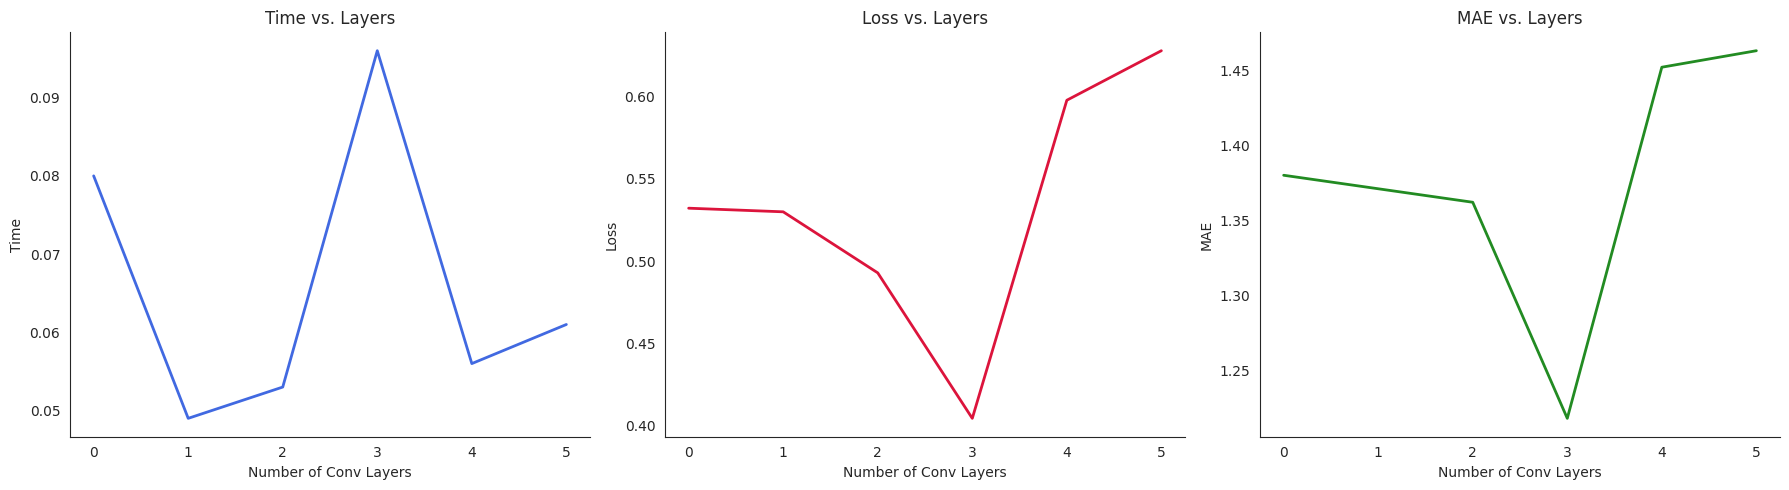

In [73]:
sns.set_style("white") # Use 'white' style for no gridlines
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['Time', 'Loss', 'MAE']
colors = ['royalblue', 'crimson', 'forestgreen']

for i, metric in enumerate(metrics):
    # We use the column names exactly as they appear in your file
    sns.lineplot(ax=axes[i], x='Number of Layers', y=metric, data=df, color=colors[i], linewidth=2) # Removed marker='o'
    axes[i].set_title(f'{metric} vs. Layers')
    axes[i].set_xlabel('Number of Conv Layers')
    axes[i].set_ylabel(metric) # Explicitly set y-label for clarity
    # Remove top and right spines for a cleaner look
    axes[i].spines[['right', 'top']].set_visible(False)

plt.tight_layout()
plt.show()

### **2. Interpretation**
Overall, we can see that having 3 convolutional layers results in the lowest MAE (1.218). While it also takes the longest time, there is a benefit to have the lowest MAE for highest prediction accuracy. The loss also appears to be lowest with 3 layers (0.4045). Increasing or decreasing the number of layers from 3 generally leads to higher MAE values, likely due to over or underfitting. This indicates that 3 convolutional layers is optimal for this small dataset. This follows the number of convolutional layers Xie et al. (2018) use, indicating that this is optimal no matter the dataset.

## **Training Dataset Size Variation**

### **1. Plotting Results**

In [74]:
file_path_2 = '/content/Bartok-ML-MatProperties/Numb_Molecules_Variation_Results'

# Read the comma-separated file into a DataFrame
df_molecules = pd.read_csv(file_path_2, sep=',')

# Display the first few rows and column info to verify correct parsing
print("Columns in Dataframe:", df_molecules.columns.tolist())
display(df_molecules.head())

# Create separate dataframes as requested
df_molecules_time = df_molecules[['Number of Molecules', 'Time']].copy()
df_molecules_loss = df_molecules[['Number of Molecules', 'Loss']].copy()
df_molecules_mae = df_molecules[['Number of Molecules', 'MAE']].copy()

print("\nDataFrame for Molecules vs. Time:")
display(df_molecules_time.head())
print("\nDataFrame for Molecules vs. Loss:")
display(df_molecules_loss.head())
print("\nDataFrame for Molecules vs. MAE:")
display(df_molecules_mae.head())

Columns in Dataframe: ['Number of Molecules', 'Time', 'Loss', 'MAE']


,Number of Molecules,Time,Loss,MAE
0,15,0.052,0.4184,1.230
1,30,0.039,0.5748,1.254
2,46000,0.039,0.0348,0.237



DataFrame for Molecules vs. Time:


,Number of Molecules,Time
0,15,0.052
1,30,0.039
2,46000,0.039



DataFrame for Molecules vs. Loss:


,Number of Molecules,Loss
0,15,0.4184
1,30,0.5748
2,46000,0.0348



DataFrame for Molecules vs. MAE:


,Number of Molecules,MAE
0,15,1.230
1,30,1.254
2,46000,0.237


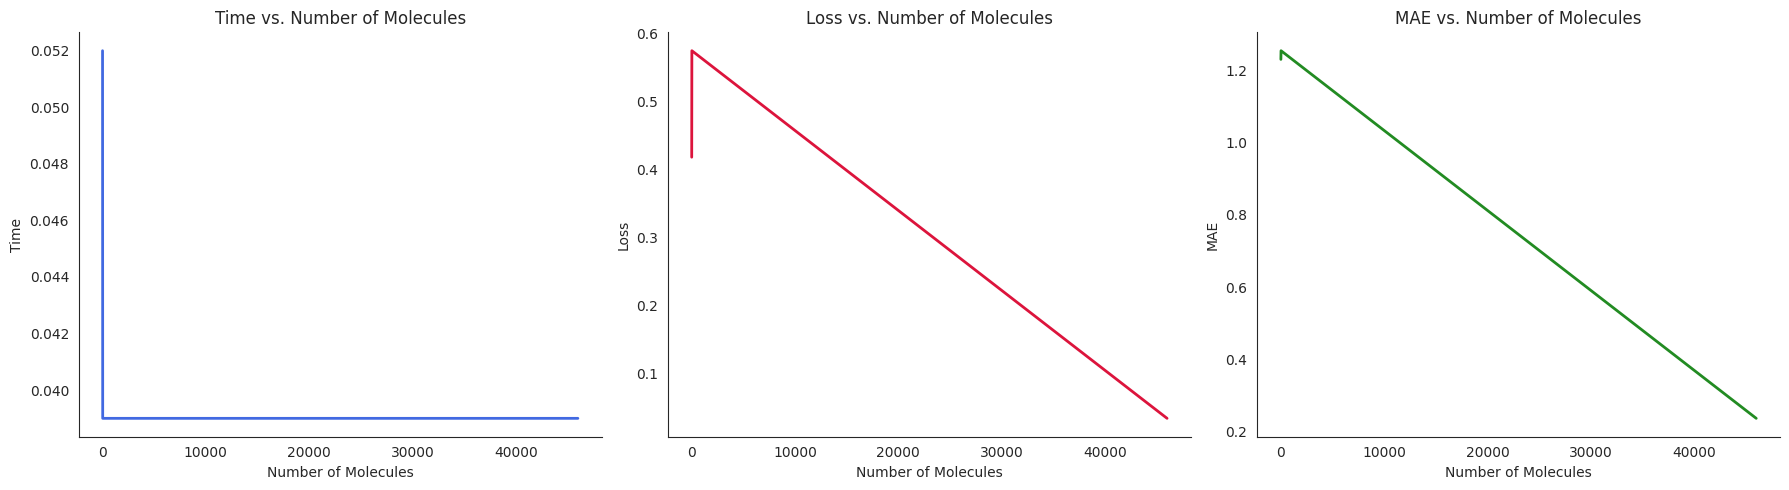

In [75]:
sns.set_style("white") # Use 'white' style for no gridlines
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['Time', 'Loss', 'MAE']
colors = ['royalblue', 'crimson', 'forestgreen']

for i, metric in enumerate(metrics):
    sns.lineplot(ax=axes[i], x='Number of Molecules', y=metric, data=df_molecules, color=colors[i], linewidth=2)
    axes[i].set_title(f'{metric} vs. Number of Molecules')
    axes[i].set_xlabel('Number of Molecules')
    axes[i].set_ylabel(metric)
    # Remove top and right spines for a cleaner look
    axes[i].spines[['right', 'top']].set_visible(False)

plt.tight_layout()
plt.show()

### **2. Interpretation**
Overall, we can see that as the number of molecules in the training dataset increases, both the Loss and MAE significantly decrease. The pretrained model (46,000 molecules) has by far the lowest Loss (0.0348) and MAE (0.237), which demonstrates the importance of a large dataset for model performance. While it takes time to curate the sheer number of data, this logically makes sense, as the model was trained on so many models that it can generalize well. Looking at the difference between 15 and 30 molecules in the training dataset, the MAE is very similar (0.024 difference), indicating that to see a larger difference in MAE, a much larger dataset would need to be used. Time remains relatively constant for the smaller datasets, but would likely increase significantly with a very large dataset, as observed with the pre-trained model. This supports the reasoning of Xie et al. (2018) to use such a large dataset of molecules to train their model.

## **T/V/T Split Variation**

### **1. Plotting Results**

In [76]:
file_path_3 = '/content/Bartok-ML-MatProperties/T_V_T_Split_Variation_Results'

# Read the comma-separated file into a DataFrame
df_split = pd.read_csv(file_path_3, sep=',')

# Display the first few rows and column info to verify correct parsing
print("Columns in Dataframe:", df_split.columns.tolist())
display(df_split.head())

# Create separate dataframes as requested
df_split_time = df_split[['Train Percent', 'Time']].copy()
df_split_loss = df_split[['Train Percent', 'Loss']].copy()
df_split_mae = df_split[['Train Percent', 'MAE']].copy()

print("\nDataFrame for Train Percent vs. Time:")
display(df_split_time.head())
print("\nDataFrame for Train Percent vs. Loss:")
display(df_split_loss.head())
print("\nDataFrame for Train Percent vs. MAE:")
display(df_split_mae.head())

Columns in Dataframe: ['Train Percent', 'Time', 'Loss', 'MAE']


,Train Percent,Time,Loss,MAE
0,40,0.037,0.6415,1.283
1,50,0.037,0.5799,1.271
2,60,0.039,0.5519,1.262
3,70,0.045,0.6522,1.162
4,80,0.039,0.5764,1.227



DataFrame for Train Percent vs. Time:


,Train Percent,Time
0,40,0.037
1,50,0.037
2,60,0.039
3,70,0.045
4,80,0.039



DataFrame for Train Percent vs. Loss:


,Train Percent,Loss
0,40,0.6415
1,50,0.5799
2,60,0.5519
3,70,0.6522
4,80,0.5764



DataFrame for Train Percent vs. MAE:


,Train Percent,MAE
0,40,1.283
1,50,1.271
2,60,1.262
3,70,1.162
4,80,1.227


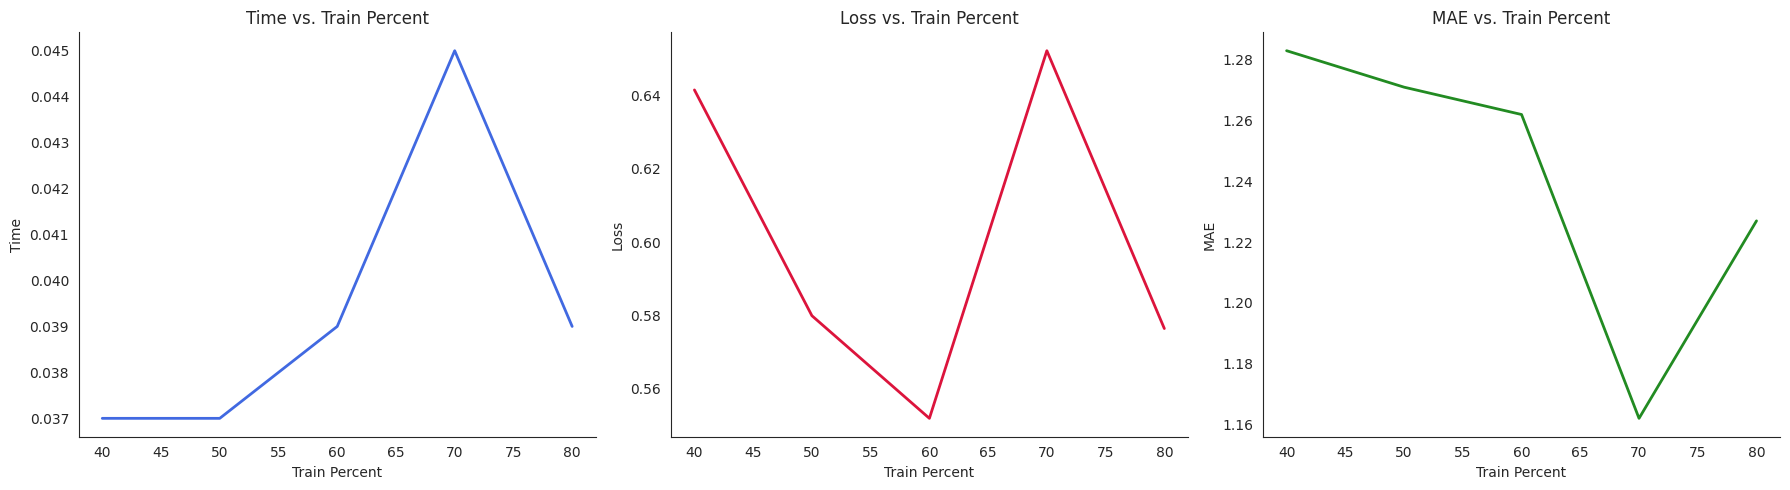

In [77]:
sns.set_style("white") # Use 'white' style for no gridlines
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['Time', 'Loss', 'MAE']
colors = ['royalblue', 'crimson', 'forestgreen']

for i, metric in enumerate(metrics):
    sns.lineplot(ax=axes[i], x='Train Percent', y=metric, data=df_split, color=colors[i], linewidth=2)
    axes[i].set_title(f'{metric} vs. Train Percent')
    axes[i].set_xlabel('Train Percent')
    axes[i].set_ylabel(metric)
    # Remove top and right spines for a cleaner look
    axes[i].spines[['right', 'top']].set_visible(False)

plt.tight_layout()
plt.show()

### **2. Interpretation**
Overall, it can be seen that a data percent of 70% for training (7/2/1 split) yields the lowest MAE (1.162). The Loss is also the lowest for this split out of all tests (0.5519). Other splits, such as 40%, 50%, 60%, and 80% training percent, show varying but generally higher MAE values, suggesting that a 70% training split is most effective for this dataset in terms of prediction accuracy. It would be interesting, moving forward, to see how this changes across various datasets and dataset sizes. As Xie et al. 2018 used a different T/V/T split of 6/2/2, it would be interesting to see as there is more data, close to their size of 46,000 molecules, if this optimal T/V/T split changes and falls to the same values that Xie et al. 2018 used.

## **Batch Size Variation**

### **1. Plotting Results**

In [78]:
file_path_4 = '/content/Bartok-ML-MatProperties/Batch_Size_Variation_Results'

# Read the comma-separated file into a DataFrame
df_batch = pd.read_csv(file_path_4, sep=',')

# Display the first few rows and column info to verify correct parsing
print("Columns in Dataframe:", df_batch.columns.tolist())
display(df_batch.head())

# Create separate dataframes as requested
df_batch_time = df_batch[['Batch Size', 'Time']].copy()
df_batch_loss = df_batch[['Batch Size', 'Loss']].copy()
df_batch_mae = df_batch[['Batch Size', 'MAE']].copy()

print("\nDataFrame for Batch Size vs. Time:")
display(df_batch_time.head())
print("\nDataFrame for Batch Size vs. Loss:")
display(df_batch_loss.head())
print("\nDataFrame for Batch Size vs. MAE:")
display(df_batch_mae.head())

Columns in Dataframe: ['Batch Size', 'Time', 'Loss', 'MAE']


,Batch Size,Time,Loss,MAE
0,3,0.052,0.6669,1.440
1,5,0.071,0.4387,1.222
2,15,0.036,0.5818,1.432
3,75,0.050,0.5371,1.367
4,175,0.037,0.5753,1.399



DataFrame for Batch Size vs. Time:


,Batch Size,Time
0,3,0.052
1,5,0.071
2,15,0.036
3,75,0.050
4,175,0.037



DataFrame for Batch Size vs. Loss:


,Batch Size,Loss
0,3,0.6669
1,5,0.4387
2,15,0.5818
3,75,0.5371
4,175,0.5753



DataFrame for Batch Size vs. MAE:


,Batch Size,MAE
0,3,1.440
1,5,1.222
2,15,1.432
3,75,1.367
4,175,1.399


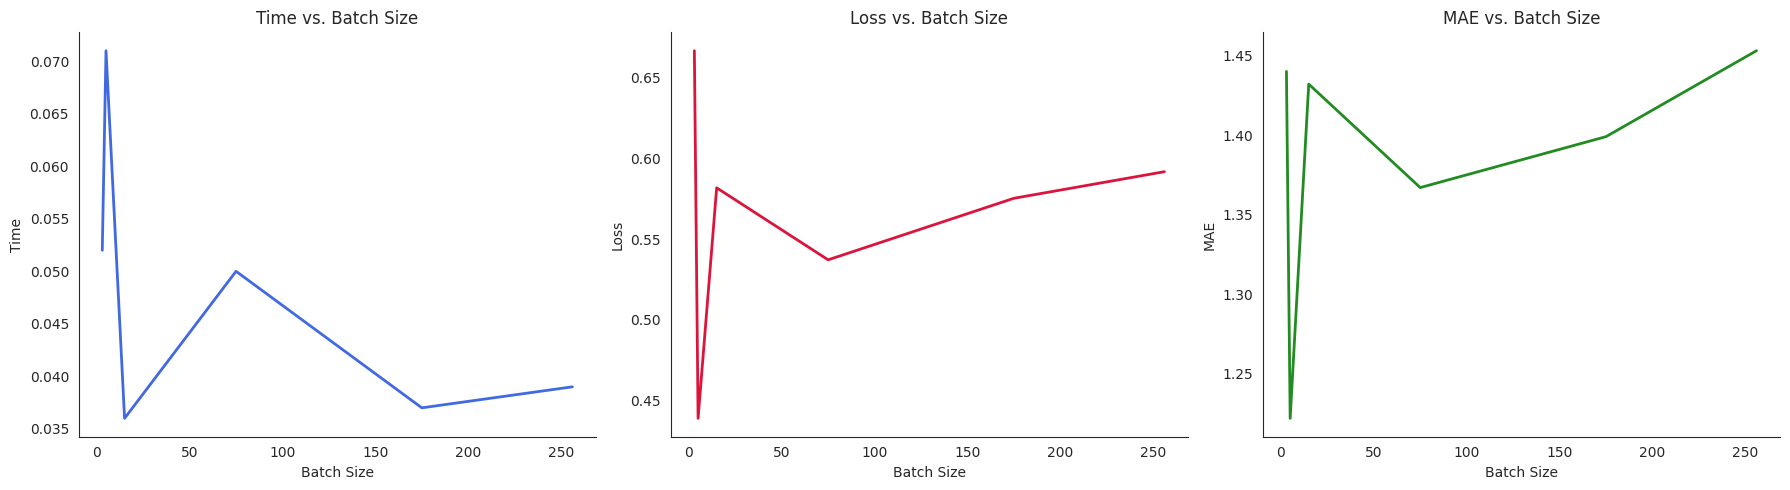

In [79]:
sns.set_style("white") # Use 'white' style for no gridlines
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['Time', 'Loss', 'MAE']
colors = ['royalblue', 'crimson', 'forestgreen']

for i, metric in enumerate(metrics):
    sns.lineplot(ax=axes[i], x='Batch Size', y=metric, data=df_batch, color=colors[i], linewidth=2)
    axes[i].set_title(f'{metric} vs. Batch Size')
    axes[i].set_xlabel('Batch Size')
    axes[i].set_ylabel(metric)
    # Remove top and right spines for a cleaner look
    axes[i].spines[['right', 'top']].set_visible(False)

plt.tight_layout()
plt.show()

### **2. Interpretation**
Overall, it is observed that a batch size of 5 results in the lowest Loss (0.4387) and MAE (1.222). A batch size of 3 has a slightly higher Loss (0.6669) and MAE (1.44), while larger batch sizes (15, 75, 175, 256) have much higher Loss and MAE values. The MAE for a batch size of 3 is near the MAE for the larger batch sizes, indicating that with a batch size of 5, it is most optimal for the model and anything much higher or lower gives poor results. The time taken for each batch size is quite similar, indicating that the choice of batch size mainly impacts model accuracy rather than computation time for this dataset. This suggests that for this small dataset, a smaller batch size (like 5), in this case, $\frac{1}{3}$ the size of the total dataset, allows the model to learn more effectively. It would be interesting to zoom in and vary this at a much smaller scale and see the effects across larger datasets.

# **Putting it all together: Making the "best" model**

## **1. "Optimal" conditions on the small dataset**

In [80]:
# Small Dataset
# 3 convolutional layers
# 7/2/1 split
# Batch size of 5
!python /content/cgcnn/main.py /content/Bartok-ML-MatProperties/root_dir_smallset --n-conv 3 --batch-size 5 --train-ratio 0.7 --val-ratio 0.2 --test-ratio 0.1  # Run the code to create the best-fit model
!mv checkpoint.pth.tar optimal_model_checkpoint.pth.tar   # Rename best model files instantly to ensure the file is saved and stored for future analysis
!mv model_best.pth.tar optimal_model_model_best.pth.tar   # Rename checkpoint file instantly to ensure the file is saved and stored for future analysis
!mv test_results.csv optimal_model_results.csv   # Rename test results file instantly to ensure the file is saved and stored for future analysis

/content/cgcnn/main.py:117: UserWarning: Dataset has less than 500 data points. Lower accuracy is expected. 
  warnings.warn('Dataset has less than 500 data points. '
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
Epoch: [0][0/2]	Time 0.043 (0.043)	Data 0.001 (0.001)	Loss 1.6699 (1.6699)	MAE 2.104 (2.104)
Test: [0/1]	Time 0.006 (0.006)	Loss 449.2486 (449.2486)	MAE 41.864 (41.864)
 * MAE 41.864
Epoch: [1][0/2]	Time 0.041 (0.041)	Data 0.001 (0.001)	Loss 17.8546 (17.8546)	MAE 8.252 (8.252)
Test: [0/1]	Time 0.006 (0.006)	Loss 0.8584 (0.8584)	MAE 1.356 (1.356)
 * MAE 1.356
Epoch: [2][0/2]	Time 0.041 (0.041)	Data 0.001 (0.001)	Loss 2.9086 (2.9086)	MAE 2.933 (2.933)
Test: [0/1]	Time 0.006 (0.006)	Loss 0.3915 (0.3915)	MAE 1.087 (1.087)
 * MAE 1.087
Epoch: [3][0/2]	Time 0.03

In [81]:
# Optimal Model Prediction
!python /content/cgcnn/predict.py /content/optimal_model_model_best.pth.tar /content/Bartok-ML-MatProperties/predict_dir # Run the model to predict the results
!mv test_results.csv optimal_model_predict_results.csv   # Rename test results file instantly to ensure the file is saved and stored for future analysis

=> loading model params '/content/optimal_model_model_best.pth.tar'
=> loaded model params '/content/optimal_model_model_best.pth.tar'
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 14 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
=> loading model '/content/optimal_model_model_best.pth.tar'
=> loaded model '/content/optimal_model_model_best.pth.tar' (epoch 27, validation 0.7902364134788513)
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
Test: [0/1]	Time 0.059 (0.059)	Loss 0.6618 (0.6618)	MAE 1.447 (1.447)
 ** MAE 1.447


## **2. "Optimal" conditions on the large dataset**

In [82]:
# Large Dataset
# 3 convolutional layers
# 7/2/1 split
# Batch size of 5
!python /content/cgcnn/main.py /content/Bartok-ML-MatProperties/root_dir_largeset --n-conv 3 --batch-size 5 --train-ratio 0.7 --val-ratio 0.2 --test-ratio 0.1  # Run the code to create the best-fit model
!mv checkpoint.pth.tar optimal_model__largeset_checkpoint.pth.tar   # Rename best model files instantly to ensure the file is saved and stored for future analysis
!mv model_best.pth.tar optimal_model_largeset_model_best.pth.tar   # Rename checkpoint file instantly to ensure the file is saved and stored for future analysis
!mv test_results.csv optimal_model_largeset_results.csv   # Rename test results file instantly to ensure the file is saved and stored for future analysis

/content/cgcnn/main.py:117: UserWarning: Dataset has less than 500 data points. Lower accuracy is expected. 
  warnings.warn('Dataset has less than 500 data points. '
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 6 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 8 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
Epoch: [0][0/5]	Time

In [86]:
# Optimal Model Prediction
!python /content/cgcnn/predict.py /content/optimal_model_largeset_model_best.pth.tar /content/Bartok-ML-MatProperties/predict_dir # Run the model to predict the results
!mv test_results.csv optimal_model_largeset_predict_results.csv   # Rename test results file instantly to ensure the file is saved and stored for future analysis

=> loading model params '/content/optimal_model_largeset_model_best.pth.tar'
=> loaded model params '/content/optimal_model_largeset_model_best.pth.tar'
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 14 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
=> loading model '/content/optimal_model_largeset_model_best.pth.tar'
=> loaded model '/content/optimal_model_largeset_model_best.pth.tar' (epoch 16, validation 0.7579997181892395)
/usr/local/lib/python3.12/dist-packages/pymatgen/core/structure.py:3117: UserWarning: Issues encountered while parsing CIF: 4 fractional coordinates rounded to ideal values to avoid issues with finite precision.
  struct = parser.parse_structures(primitive=primitive)[0]
Test: [0/1]	Time 0.052 (0.052)	Loss 1.0491 (1.0491)	MAE 1.217 (1.217)
 ** MAE 1.217


## **Final Takeaways**
By combining these "best" conditions found through testing, it is possible to optimize the model, even with such a small dataset. While it is nowhere near the MAE of the pretrained band gap model (0.237), it is improved compared to the results of just varying one variable.
*(This is, given when Aletta completed these runs. Due to natural variations for Neural Networks, the results may vary and not be fully reproducible)*

When running the same "optimal" conditions for the 30 molecule model, it is clear that these "optimal" conditions do not always translate across datasets. The MAE for the "optimal" conditions on the 30 molecule dataset was higher than for the 15 molecule dataset (1.357).

This gives an important lesson to see that prior to building such a model or using it for predictions, it is crucial to find the optimal hyperparamenters and conditions for training. The best hyperparameters and conditions are not applicable across datasets, in both size, and what they contain. It is of crucial to ensure optimal parameters for each separate model and conditions. By doing this, it is possible to decrease the MAE and optimize the model so it is best in accuracy, interpretation, and generalization!

At this point you likely have many folders for each variation, including the best models. These include supplementary information about the results and predictions from the model. Feel free to take a look to learn more about how this model works and how it outputs its data!